# Compare color changes with metrics

## Purpose

This is an isolated notebook to compare the mean color with the metrics produced as part of the Coma galaxy/CSS colour pipeline.

The metrics csv file will be called `"../Coma_CSS_color/data/metrics_df_fiducial_orig_recal.csv"` for the new cal data.

Initially this will be diagnostic checking, to establish wether there is a correlation between the $\Delta C$ and the metric $\Delta f_\mathrm{b}$.


## Load and verify the new quantities

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, pearsonr, linregress

metrics_df = pd.read_csv(
    "../Coma_CSS_color/data/metrics_df_fiducial_orig_recal.csv"
)

PB_METRIC = "Delta_Pblue_mean_bgsub"
COLOR_METRIC = "Delta_mean_color_bgsub"

required = [
    "mean_color",
    "mean_color_bgsub",
    COLOR_METRIC,
    PB_METRIC,
]

for col in required:
    print(f"{col:30s}", col in metrics_df.columns)



mean_color                     True
mean_color_bgsub               True
Delta_mean_color_bgsub         True
Delta_Pblue_mean_bgsub         True


First, a quick sanity check

In [27]:
display(
    metrics_df[required].describe().T
)


,count,mean,std,min,25%,50%,75%,max
mean_color,130.0,1.506787,0.101059,1.230154,1.447680,1.507925,1.568970,1.809049
mean_color_bgsub,93.0,0.402890,0.748270,-3.091910,0.051206,0.516185,0.846209,1.590135
Delta_mean_color_bgsub,93.0,-0.111028,0.722310,-3.703572,-0.391312,-0.048577,0.394688,1.003340
Delta_Pblue_mean_bgsub,93.0,-0.040809,0.241697,-1.200813,-0.137585,0.007485,0.115110,0.310797


## Construct a common sample

IMPORTANT: we need to make sure we use exactly the same galaxies for the two diagnostics.

Hopefully, this will be close to the fiducial $N=93$. If it drops substantially, we investigate before going further.

In [31]:
compare_cols = [
    PB_METRIC,
    COLOR_METRIC,
]

df_cmp = (
    metrics_df[compare_cols]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

print(f"Common sample N = {len(df_cmp)}")


Common sample N = 93


# Key referee point-1 comparison

We expect the sign to be negative:

$$ \Delta C>0 \quad\text{(redder than expected)} $$

should correspond to

$$Δf_\mathrm{b}<0.$$

## Interpretation

There are roughly three regimes:

- $|\rho|\sim0.95-1$: the referee's “mostly a remapping of color” argument becomes very strong.
- $|\rho|\sim0.6-0.8$: clearly related, as expected, but there may be appreciable information in the distribution shape beyond its mean.
- modest $|\rho|$: strong evidence that the GMM statistic is capturing something materially different from mean color.

These are not formal thresholds for the paper; just useful instincts for interpretation.


In [32]:
x = df_cmp[COLOR_METRIC]
y = df_cmp[PB_METRIC]

rho, p_rho = spearmanr(x, y)
r, p_r = pearsonr(x, y)
fit = linregress(x, y)

print(f"N            = {len(df_cmp)}")
print(f"Spearman rho = {rho:.4f}  (p={p_rho:.3g})")
print(f"Pearson r    = {r:.4f}  (p={p_r:.3g})")
print(f"Slope        = {fit.slope:.4f}")
print(f"Intercept    = {fit.intercept:+.4f}")



N            = 93
Spearman rho = 0.8793  (p=4.56e-31)
Pearson r    = 0.9316  (p=9.15e-42)
Slope        = 0.3117
Intercept    = -0.0062


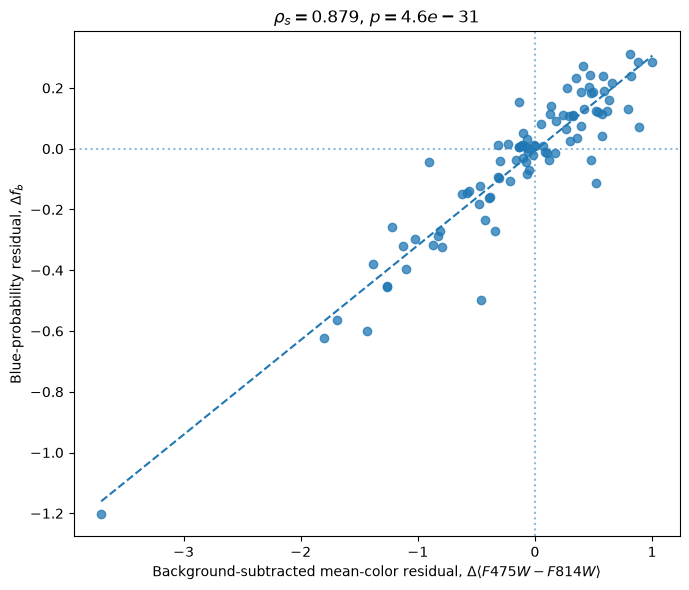

In [33]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    x,
    y,
    alpha=0.75
)

xx = np.linspace(x.min(), x.max(), 200)

ax.plot(
    xx,
    fit.intercept + fit.slope * xx,
    "--"
)

ax.axhline(0, linestyle=":", alpha=0.5)
ax.axvline(0, linestyle=":", alpha=0.5)

ax.set_xlabel(
    r"Background-subtracted mean-color residual, "
    r"$\Delta\langle F475W-F814W\rangle$"
)
ax.set_ylabel(
    r"Blue-probability residual, $\Delta f_b$"
)

ax.set_title(
    rf"$\rho_s={rho:.3f}$, $p={p_rho:.2g}$"
)

plt.tight_layout()
plt.show()

## Compare with environmental metrics


In [34]:
ENV_VARS = {
    "Cluster-centric radius": "R_bcg_mid_arcmin",
    "Local GC density": "gc_bg_voronoi_density_arcsec2_inv",
    "BCG tidal proxy": "tidal_proxy",
    "Nearest BCG distance": "R_nearBCG_arcmin",
}


In [35]:
rows = []

for label, env in ENV_VARS.items():

    sub = metrics_df[
        [env, PB_METRIC, COLOR_METRIC]
    ].replace([np.inf, -np.inf], np.nan).dropna()

    rho_pb, p_pb = spearmanr(
        sub[env],
        sub[PB_METRIC]
    )

    rho_col, p_col = spearmanr(
        sub[env],
        sub[COLOR_METRIC]
    )

    rows.append({
        "Environment": label,
        "N": len(sub),
        "rho_Delta_fb": rho_pb,
        "p_Delta_fb": p_pb,
        "rho_Delta_color": rho_col,
        "p_Delta_color": p_col,
    })

env_compare = pd.DataFrame(rows)

display(env_compare, )


,Environment,N,rho_Delta_fb,p_Delta_fb,rho_Delta_color,p_Delta_color
0,Cluster-centric radius,93,0.278476,0.006874,0.279848,0.006592
1,Local GC density,93,-0.442004,0.000009,-0.414819,0.000036
2,BCG tidal proxy,93,-0.250157,0.015590,-0.220868,0.033377
3,Nearest BCG distance,93,0.260677,0.011614,0.208984,0.044392


## Plot Local Density

As this is the 'headline' result we'll plot this first.

In [36]:
plot_df = metrics_df[
    [
        "gc_bg_voronoi_density_arcsec2_inv",
        PB_METRIC,
        COLOR_METRIC
    ]
].replace([np.inf, -np.inf], np.nan).dropna().copy()

plot_df["log_density"] = np.log10(
    plot_df["gc_bg_voronoi_density_arcsec2_inv"]
)


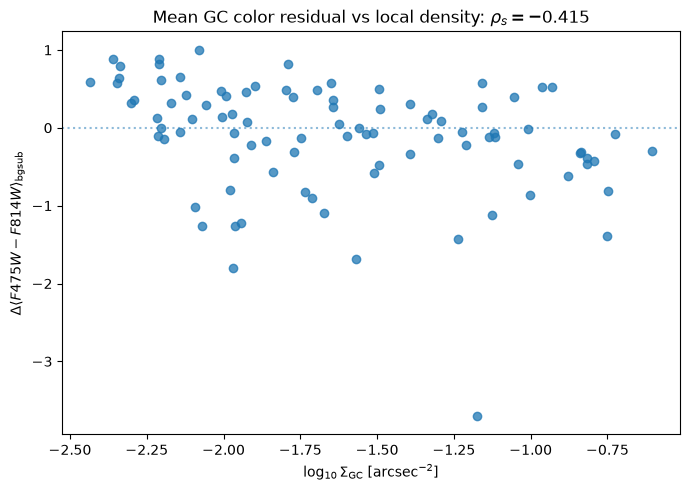

In [37]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    plot_df["log_density"],
    plot_df[COLOR_METRIC],
    alpha=0.75
)

rho, p = spearmanr(
    plot_df["log_density"],
    plot_df[COLOR_METRIC]
)

ax.axhline(0, linestyle=":", alpha=0.5)

ax.set_xlabel(
    r"$\log_{10}\Sigma_{\rm GC}$ [arcsec$^{-2}$]"
)
ax.set_ylabel(
    r"$\Delta\langle F475W-F814W\rangle_{\rm bgsub}$"
)

ax.set_title(
    rf"Mean GC color residual vs local density: "
    rf"$\rho_s={rho:.3f}$"
)

plt.tight_layout()
plt.show()


# Initial interpretation

The initial result strongly suggests that $\Delta f_b$ is not simply equivalent to a background-subtracted mean-color shift, but the mean-color estimator must first be restricted to galaxies for which the background-subtracted population is sufficiently *well determined*.

By well-determined I mean that some of the background-subtracted mean colors have some frankly unphysical values!

# Analyse extreme points

## Identify galaxies


In [14]:
check_cols = [
    "name",
    "mean_color",
    "mean_color_bgsub",
    "Delta_mean_color_bgsub",
    "Delta_Pblue_mean_bgsub",
    "N_inner_color",
    "N_annulus_color",
    "N_eff_bgsub_Pblue",
]

display(
    metrics_df[check_cols]
    .dropna(subset=["Delta_mean_color_bgsub"])
    .assign(
        abs_Delta_color=lambda x:
            np.abs(x["Delta_mean_color_bgsub"])
    )
    .sort_values(
        "abs_Delta_color",
        ascending=False
    )
    .head(20)
)



,name,mean_color,mean_color_bgsub,Delta_mean_color_bgsub,Delta_Pblue_mean_bgsub,N_inner_color,N_annulus_color,N_eff_bgsub_Pblue,abs_Delta_color
156,NGC 4883,1.578614,6.083904,4.438967,-0.322755,54,182,-3.761421,4.438967
60,LEDA 44637,1.870597,3.911454,2.416046,NaN,3,7,-0.184042,2.416046
139,LEDA 1821341,1.230154,-0.864297,-2.381600,NaN,7,26,0.500000,2.381600
70,SDSS J130005.34+275628.8,1.395060,-0.359713,-1.813327,0.004298,16,62,0.500000,1.813327
50,SDSS J130026.15+280032.0,1.409840,0.118616,-1.377110,NaN,9,33,0.750000,1.377110
94,IC 3968,1.662751,2.923170,1.327336,-0.270182,31,113,2.000000,1.327336
65,SDSS J130032.48+275833.2,1.446883,0.164316,-1.297398,-0.031501,15,58,0.500000,1.297398
106,LEDA 44644,1.629701,2.828028,1.237738,-0.235112,119,440,3.750000,1.237738
68,LEDA 126785,1.330310,0.375512,-1.096754,0.153662,11,38,1.500000,1.096754
67,SDSS J130020.39+280413.9,1.235873,0.694050,-0.753517,NaN,7,23,1.250000,0.753517


## Check columns again!

In [17]:
keywords = [
    "eff",
]

for keyword in keywords:
    matches = [
        c for c in metrics_df
        if keyword.lower() in c.lower()
    ]

    print(f"\n{keyword}:")
    print(matches)



eff:
['A_ap_eff', 'A_bg_eff', 'A_ap_eff_over_geom', 'A_bg_eff_over_geom', 'alpha_eff', 'N_eff_bgsub_color', 'N_eff_bgsub_Pblue']


In [20]:
check_cols = [
    "name",
    "mean_color",
    "mean_color_bgsub",
    "Delta_mean_color_bgsub",
    "Delta_Pblue_mean_bgsub",
    "N_inner_color",
    "N_annulus_color",
    "N_eff_bgsub_color",
    "N_eff_bgsub_Pblue",
    "alpha_eff",
]

extreme_color = (
    metrics_df[check_cols]
    .dropna(subset=["Delta_mean_color_bgsub"])
    .assign(
        abs_Delta_color=lambda x: np.abs(x["Delta_mean_color_bgsub"])
    )
    .sort_values("abs_Delta_color", ascending=False)
)

display(extreme_color.head(20))


,name,mean_color,mean_color_bgsub,Delta_mean_color_bgsub,Delta_Pblue_mean_bgsub,N_inner_color,N_annulus_color,N_eff_bgsub_color,N_eff_bgsub_Pblue,alpha_eff,abs_Delta_color
156,NGC 4883,1.578614,6.083904,4.438967,-0.322755,54,182,1.508076,-3.761421,0.288417,4.438967
60,LEDA 44637,1.870597,3.911454,2.416046,NaN,3,7,0.451951,-0.184042,0.364007,2.416046
139,LEDA 1821341,1.230154,-0.864297,-2.381600,NaN,7,26,0.500000,0.500000,0.250000,2.381600
70,SDSS J130005.34+275628.8,1.395060,-0.359713,-1.813327,0.004298,16,62,0.500000,0.500000,0.250000,1.813327
50,SDSS J130026.15+280032.0,1.409840,0.118616,-1.377110,NaN,9,33,0.750000,0.750000,0.250000,1.377110
94,IC 3968,1.662751,2.923170,1.327336,-0.270182,31,113,2.750000,2.000000,0.250000,1.327336
65,SDSS J130032.48+275833.2,1.446883,0.164316,-1.297398,-0.031501,15,58,0.500000,0.500000,0.250000,1.297398
106,LEDA 44644,1.629701,2.828028,1.237738,-0.235112,119,440,9.000000,3.750000,0.250000,1.237738
68,LEDA 126785,1.330310,0.375512,-1.096754,0.153662,11,38,1.500000,1.500000,0.250000,1.096754
67,SDSS J130020.39+280413.9,1.235873,0.694050,-0.753517,NaN,7,23,1.250000,1.250000,0.250000,0.753517


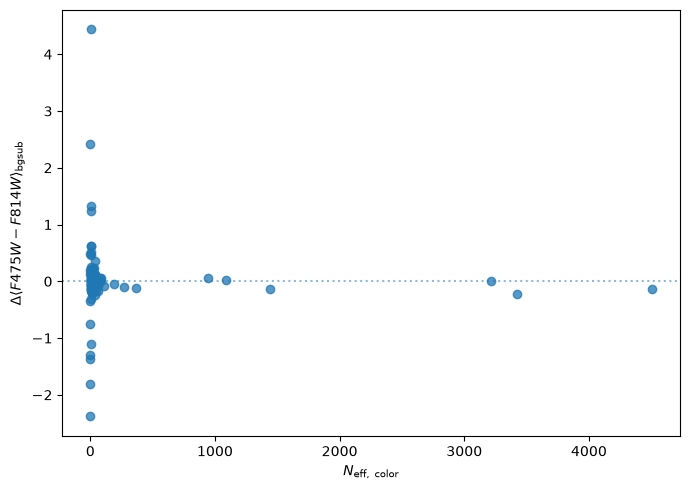

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))

sub = metrics_df[
    ["N_eff_bgsub_color", "Delta_mean_color_bgsub"]
].replace([np.inf, -np.inf], np.nan).dropna()

ax.scatter(
    sub["N_eff_bgsub_color"],
    sub["Delta_mean_color_bgsub"],
    alpha=0.75
)

ax.axhline(0, linestyle=":", alpha=0.5)

ax.set_xlabel(r"$N_{\rm eff,\ color}$")
ax.set_ylabel(
    r"$\Delta\langle F475W-F814W\rangle_{\rm bgsub}$"
)

plt.tight_layout()
plt.show()

## Investigate low effective counts causing instability (in residuals)

In [21]:
print(metrics_df["min_gc_for_Pblue"].value_counts())

min_gc_for_Pblue
10    174
Name: count, dtype: int64


In [22]:
PB = "Delta_Pblue_mean_bgsub"
COL = "Delta_mean_color_bgsub"

sub = metrics_df[
    np.isfinite(metrics_df[PB])
    & np.isfinite(metrics_df[COL])
    & (metrics_df["N_eff_bgsub_color"] >= metrics_df["min_gc_for_Pblue"])
    & (metrics_df["N_eff_bgsub_Pblue"] >= metrics_df["min_gc_for_Pblue"])
].copy()

rho, p = spearmanr(sub[COL], sub[PB])

print(f"N = {len(sub)}")
print(f"Spearman rho = {rho:.4f}, p = {p:.3g}")


N = 48
Spearman rho = -0.1794, p = 0.222


## Investigate count discrepancies

In [24]:
count_check = metrics_df[
    [
        "name",
        "N_inner_color",
        "N_inner_Pblue",
        "N_annulus_color",
        "N_annulus_Pblue",
        "N_eff_bgsub_color",
        "N_eff_bgsub_Pblue",
    ]
].copy()

count_check["dN_inner"] = (
    count_check["N_inner_color"]
    - count_check["N_inner_Pblue"]
)

count_check["dN_annulus"] = (
    count_check["N_annulus_color"]
    - count_check["N_annulus_Pblue"]
)

display(count_check[
    [
        "name",
        "dN_inner",
        "dN_annulus",
        "N_eff_bgsub_color",
        "N_eff_bgsub_Pblue",
    ]
].describe())

,dN_inner,dN_annulus,N_eff_bgsub_color,N_eff_bgsub_Pblue
count,174.000000,174.000000,134.000000,134.000000
mean,6.229885,7.471264,123.713576,119.271408
std,26.105699,24.990097,580.429557,561.338096
min,0.000000,0.000000,-183.360714,-148.722097
25%,0.000000,0.000000,-0.709038,-1.123412
50%,0.000000,0.000000,4.625000,4.000000
75%,3.000000,3.750000,22.375000,20.750000
max,206.000000,251.000000,4505.431053,4325.481626


In [25]:
display(
    count_check[
        (count_check["dN_inner"] != 0) |
        (count_check["dN_annulus"] != 0)
    ].head(30)
)


,name,N_inner_color,N_inner_Pblue,N_annulus_color,N_annulus_Pblue,N_eff_bgsub_color,N_eff_bgsub_Pblue,dN_inner,dN_annulus
0,LEDA 126771,1847,1816,1890,1847,1084.518041,1070.865514,31,43
1,SDSS J130033.33+275849.3,13,13,31,29,5.250000,5.750000,0,2
2,2MASX J12592536+2756038,73,68,119,116,43.250000,39.000000,5,3
8,SDSS J125928.50+280109.3,10,10,29,27,2.750000,3.250000,0,2
9,LEDA 1821898,23,19,55,54,9.250000,5.500000,4,1
11,SDSS J130036.67+275427.4,6,6,14,12,2.500000,3.000000,0,2
13,LEDA 1822726,24,23,49,49,11.750000,10.750000,1,0
14,SDSS J130027.87+275916.2,5,5,5,4,3.750000,4.000000,0,1
15,SDSS J130044.10+280215.4,22,22,88,85,0.000000,0.750000,0,3
18,LEDA 126788,3,3,10,9,0.500000,0.750000,0,1


# Sample-matching check. 

The raw color statistic includes a small number of bright $(F814W<23)$ CSS for which $P_{\rm blue}$ is undefined, resulting in slightly different inner and annular sample sizes. The definitive color comparison will therefore be recalculated using only objects with finite $P_{\rm blue}$, ensuring identical CSS membership, spatial selection, background scaling and galaxy eligibility for the two diagnostics. The temporary $N_{\rm eff}\ge10$ restriction is not retained because the existing minimum-GC requirement refers to the number of usable inner-aperture objects rather than the background-subtracted effective count.

# Check after update for sample matching (Color to Pblue)



In [30]:
print((metrics_df["N_inner_color"] == metrics_df["N_inner_Pblue"]).all())

print((metrics_df["N_annulus_color"] == metrics_df["N_annulus_Pblue"]).all())


True
True


In [38]:
from scipy.stats import spearmanr

pairs = [
    (
        "Inner raw",
        "mean_color_inner_raw",
        "Pblue_mean_inner_raw"
    ),
    (
        "Annulus raw",
        "mean_color_annulus",
        "Pblue_mean_annulus"
    ),
    (
        "Background subtracted",
        "mean_color_bgsub",
        "Pblue_mean_bgsub"
    ),
    (
        "MV residual",
        "Delta_mean_color_bgsub",
        "Delta_Pblue_mean_bgsub"
    ),
]

for label, xcol, ycol in pairs:

    sub = metrics_df[
        [xcol, ycol]
    ].replace([np.inf, -np.inf], np.nan).dropna()

    rho, p = spearmanr(
        sub[xcol],
        sub[ycol]
    )

    print(
        f"{label:25s} "
        f"N={len(sub):3d}  "
        f"rho={rho:+.4f}  "
        f"p={p:.3g}"
    )

Inner raw                 N=130  rho=-0.8230  p=3.09e-33
Annulus raw               N=139  rho=-0.7905  p=5.71e-31
Background subtracted     N= 93  rho=+0.9052  p=1.38e-35
MV residual               N= 93  rho=+0.8793  p=4.56e-31


## Check the effective count distribution

In [39]:
neff = metrics_df["N_eff_bgsub_Pblue"]

print(neff.describe())

print(f"N total       = {np.isfinite(neff).sum()}")
print(f"N_eff <= 0    = {(neff <= 0).sum()}")
print(f"0 < N_eff < 5 = {((neff > 0) & (neff < 5)).sum()}")
print(f"5–10          = {((neff >= 5) & (neff < 10)).sum()}")
print(f"N_eff >= 10   = {(neff >= 10).sum()}")


count     134.000000
mean      119.271408
std       561.338096
min      -148.722097
25%        -1.123412
50%         4.000000
75%        20.750000
max      4325.481626
Name: N_eff_bgsub_Pblue, dtype: float64
N total       = 134
N_eff <= 0    = 42
0 < N_eff < 5 = 31
5–10          = 13
N_eff >= 10   = 48


# Check background correction (see sign-change above)

There is an error in the background correction, interestingly as intimated by the referee in his point 2, but now the samples are matched for each galaxy, the `N_eff` is not the denominator in the existing background correction `background_correct_scalar` function. The current function instead does:

$$ v_{\rm corr} = v_{\rm in} - v_{\rm bg} \frac{n_{\rm bg}}{n_{\rm in}} \frac{A_{\rm in}}{A_{\rm bg}}. $$

If we define

$$ r_{\rm bg} = \frac{A_{\rm in}}{A_{\rm bg}} \frac{n_{\rm bg}}{n_{\rm in}}. $$

Then simply

$$ \boxed{v_{\rm corr}=v_{\rm in}-r_{\rm bg}v_{\rm bg}}. $$

For a mean quantity, that's equivalent to

$$ v_{\rm corr} = \frac{ n_{\rm in}v_{\rm in} -\alpha n_{\rm bg}v_{\rm bg} }{ n_{\rm in} }, $$

where $\alpha=A_{\rm in}/A_{\rm bg}$.

So my current `Pblue_mean_bgsub` is not the mean $P_{\rm blue}$ of the estimated residual galaxy GC population. That quantity would instead be

$$\frac{ n_{\rm in}v_{\rm in} -\alpha n_{\rm bg}v_{\rm bg} }{ n_{\rm in} - \alpha n_{\rm bg} }.$$

So, before making changes, let's calculate the actual subtraction strength for each galaxy:

In [40]:
metrics_df["r_bg"] = (
    metrics_df["alpha_eff"]
    * metrics_df["N_annulus_Pblue"]
    / metrics_df["N_inner_Pblue"]
)


/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_23396/1536855579.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metrics_df["r_bg"] = (


In [41]:
print(metrics_df["r_bg"].describe())


count    133.000000
mean            inf
std             NaN
min        0.050000
25%        0.457283
50%        0.718491
75%        1.146517
max             inf
Name: r_bg, dtype: float64


In [42]:
test_vars = [
    "Pblue_mean_bgsub",
    "Delta_Pblue_mean_bgsub",
    "mean_color_bgsub",
    "Delta_mean_color_bgsub",
]

for var in test_vars:
    sub = metrics_df[
        ["r_bg", var]
    ].replace([np.inf, -np.inf], np.nan).dropna()

    rho, p = spearmanr(
        sub["r_bg"],
        sub[var]
    )

    print(
        f"{var:30s} "
        f"N={len(sub):3d} "
        f"rho={rho:+.4f} "
        f"p={p:.3g}"
    )



Pblue_mean_bgsub               N= 93 rho=-0.9437 p=1.74e-45
Delta_Pblue_mean_bgsub         N= 93 rho=-0.8825 p=1.47e-31
mean_color_bgsub               N= 93 rho=-0.9908 p=6.31e-81
Delta_mean_color_bgsub         N= 93 rho=-0.9248 p=5.73e-40


In [43]:
for label, env in ENV_VARS.items():

    sub = metrics_df[
        ["r_bg", env]
    ].replace([np.inf, -np.inf], np.nan).dropna()

    rho, p = spearmanr(
        sub["r_bg"],
        sub[env]
    )

    print(
        f"{label:25s} "
        f"N={len(sub):3d} "
        f"rho={rho:+.4f} "
        f"p={p:.3g}"
    )


Cluster-centric radius    N=130 rho=-0.1160 p=0.189
Local GC density          N=130 rho=+0.2953 p=0.000647
BCG tidal proxy           N=130 rho=+0.0895 p=0.311
Nearest BCG distance      N=130 rho=-0.1339 p=0.129


In [44]:
reconstructed = (
    metrics_df["Pblue_mean"]
    -
    metrics_df["r_bg"]
    * metrics_df["Pblue_mean_annulus"]
)

diff = (
    reconstructed
    - metrics_df["Pblue_mean_bgsub"]
)

print(diff.abs().describe())


count    9.300000e+01
mean     1.129249e-16
std      1.147871e-16
min      0.000000e+00
25%      5.551115e-17
50%      9.714451e-17
75%      1.509209e-16
max      7.216450e-16
dtype: float64


In [45]:
science = metrics_df[
    np.isfinite(metrics_df["Delta_Pblue_mean_bgsub"])
].copy()

science["r_bg"] = (
    science["alpha_eff"]
    * science["N_annulus_Pblue"]
    / science["N_inner_Pblue"]
)

for label, env in ENV_VARS.items():

    sub = science[["r_bg", env]].dropna()

    rho, p = spearmanr(
        sub["r_bg"],
        sub[env]
    )

    print(
        f"{label:25s} "
        f"N={len(sub):3d} "
        f"rho={rho:+.4f} p={p:.3g}"
    )


Cluster-centric radius    N= 93 rho=-0.2831 p=0.00596
Local GC density          N= 93 rho=+0.3719 p=0.000242
BCG tidal proxy           N= 93 rho=+0.2017 p=0.0526
Nearest BCG distance      N= 93 rho=-0.2547 p=0.0138


## Partial Spearman correlation

In [46]:
from scipy.stats import spearmanr
import numpy as np

sub = science[
    [
        "Delta_Pblue_mean_bgsub",
        "gc_bg_voronoi_density_arcsec2_inv",
        "r_bg"
    ]
].dropna()

x = sub["Delta_Pblue_mean_bgsub"]
y = sub["gc_bg_voronoi_density_arcsec2_inv"]
z = sub["r_bg"]

rho_xy, _ = spearmanr(x, y)
rho_xz, _ = spearmanr(x, z)
rho_yz, _ = spearmanr(y, z)

rho_partial = (
    rho_xy - rho_xz * rho_yz
) / np.sqrt(
    (1 - rho_xz**2) *
    (1 - rho_yz**2)
)

print(f"rho(Delta_fb, density)       = {rho_xy:+.4f}")
print(f"rho(Delta_fb, r_bg)          = {rho_xz:+.4f}")
print(f"rho(density, r_bg)           = {rho_yz:+.4f}")
print(f"partial rho | r_bg           = {rho_partial:+.4f}")


rho(Delta_fb, density)       = -0.4420
rho(Delta_fb, r_bg)          = -0.8825
rho(density, r_bg)           = +0.3719
partial rho | r_bg           = -0.2607


## Check local-density signal in the uncorrected inner-aperture $P_{\rm blue}$ statistic

In [47]:
tests = [
    "Pblue_mean_inner_raw",
    "Pblue_mean_bgsub",
    "Delta_Pblue_mean_bgsub",
]

density = "gc_bg_voronoi_density_arcsec2_inv"

for metric in tests:

    sub = metrics_df[
        [metric, density]
    ].replace([np.inf, -np.inf], np.nan).dropna()

    rho, p = spearmanr(
        sub[metric],
        sub[density]
    )

    print(
        f"{metric:30s} "
        f"N={len(sub):3d} "
        f"rho={rho:+.4f} p={p:.3g}"
    )


Pblue_mean_inner_raw           N=130 rho=-0.3384 p=8.24e-05
Pblue_mean_bgsub               N= 93 rho=-0.4084 p=4.82e-05
Delta_Pblue_mean_bgsub         N= 93 rho=-0.4420 p=9.18e-06


In [49]:
science = metrics_df[
    np.isfinite(metrics_df["Delta_Pblue_mean_bgsub"])
].copy()

density = "gc_bg_voronoi_density_arcsec2_inv"

for metric in [
    "Pblue_mean_inner_raw",
    "Pblue_mean_annulus",
    "Pblue_mean_bgsub",
    "Delta_Pblue_mean_bgsub",
]:
    sub = science[[metric, density]].dropna()

    rho, p = spearmanr(sub[metric], sub[density])

    print(
        f"{metric:30s} "
        f"N={len(sub):3d} "
        f"rho={rho:+.4f} p={p:.3g}"
    )


Pblue_mean_inner_raw           N= 93 rho=-0.2823 p=0.00612
Pblue_mean_annulus             N= 93 rho=-0.6167 p=4.67e-11
Pblue_mean_bgsub               N= 93 rho=-0.4084 p=4.82e-05
Delta_Pblue_mean_bgsub         N= 93 rho=-0.4420 p=9.18e-06


On the same 93 galaxies:

$$ \rho(\langle P_{\rm blue}\rangle_{\rm inner},\Sigma_{\rm GC})=-0.282 $$

but

$$ \boxed{\rho(\langle P_{\rm blue}\rangle_{\rm ann},\Sigma_{\rm GC})=-0.617.} $$

So the annular population itself has a very strong environmental trend. At higher local GC density, the annular CSS population has lower mean $P_{\rm blue}$ — i.e., is more red-weighted according to the GMM.

That matters for interpreting the correction:

$$ P_{\rm corr} = P_{\rm in}-r_{\rm bg}P_{\rm ann}. $$

At high density, three things happen simultaneously:

- $P_{\rm in}$ decreases → drives $P_{\rm corr}$ downward.
- $r_{\rm bg}$ increases → drives $P_{\rm corr}$ downward.
- $P_{\rm ann}$ decreases → actually drives $P_{\rm corr}$ upward, because currently I subtract a smaller $P_{\rm blue}$ contribution.

So the very strong annulus-color trend is not itself capable of manufacturing the negative $\Delta f_b$-density relation. In isolation it would partially oppose it.

That's an interesting fact, but the concern instead becomes that the number of objects being subtracted, represented by $r_{\rm bg}$, increases with density strongly enough to outweigh that effect.

We can quantify this very cleanly before doing the permutation test, using counterfactual versions of the existing estimator.

## Counterfactual version of existing estimator

This should gives us an intuitive decomposition:

- inner_only — the environmental trend actually present inside the galaxy aperture.
- fixed_r — what happens if background composition varies with environment but every galaxy receives the same amount of subtraction.
- fixed_Pann — what happens if the amount of subtraction varies but the annulus has the same mean $P_{\rm blue}$ everywhere.
- actual — the submitted estimator


In [50]:
density = "gc_bg_voronoi_density_arcsec2_inv"

s = science[
    [
        density,
        "Pblue_mean_inner_raw",
        "Pblue_mean_annulus",
        "r_bg"
    ]
].dropna().copy()

Pin  = s["Pblue_mean_inner_raw"]
Pann = s["Pblue_mean_annulus"]
r    = s["r_bg"]

r_med    = np.median(r)
Pann_med = np.median(Pann)

# Actual submitted estimator
s["actual"] = Pin - r * Pann

# Let annulus composition vary, but remove variation in subtraction strength
s["fixed_r"] = Pin - r_med * Pann

# Let subtraction strength vary, but hold annulus composition fixed
s["fixed_Pann"] = Pin - r * Pann_med

# Raw inner population
s["inner_only"] = Pin

for col in ["inner_only", "fixed_r", "fixed_Pann", "actual"]:
    rho, p = spearmanr(s[col], s[density])

    print(
        f"{col:12s}: "
        f"rho={rho:+.4f}, p={p:.3g}"
    )

inner_only  : rho=-0.2823, p=0.00612
fixed_r     : rho=+0.0395, p=0.707
fixed_Pann  : rho=-0.4965, p=4.17e-07
actual      : rho=-0.4050, p=5.66e-05


## Interpretation

The four results tell a coherent story:

| Version | $\rho$ with local density | Interpretation |
|---------|:-------------------------:|----------------|
|inner only | $-0.282$ | A significant trend exists before subtraction |
|fixed $r_{\rm bg}$ | $+0.040$ | Inner and annular population trends essentially <br> cancel if subtraction strength is held constant |
|fixed $P_{\rm ann}$ | $-0.497$ | Allowing subtraction strength to vary strongly <br> amplifies the negative trend |
|actual | $-0.405$ | Annular population variation partly counteracts that amplification |

The *raw* inner-aperture population already exhibits a significant density dependence. The composition of the local annular population varies even more strongly with density, but in a direction that would suppress rather than generate the observed corrected trend. The enhancement of the final correlation is instead associated primarily with the density dependence of the amplitude of the background subtraction.

## Calculate the background term

$$B=r_{\rm bg}P_{\rm ann}$$

In [51]:
science["bg_Pblue_term"] = (
    science["r_bg"] *
    science["Pblue_mean_annulus"]
)

sub = science[
    ["bg_Pblue_term", "gc_bg_voronoi_density_arcsec2_inv"]
].dropna()

rho, p = spearmanr(
    sub["bg_Pblue_term"],
    sub["gc_bg_voronoi_density_arcsec2_inv"]
)

print(f"rho(background term, density) = {rho:+.4f}, p={p:.3g}")


rho(background term, density) = +0.2721, p=0.00832


In [52]:
Pin_med  = science["Pblue_mean_inner_raw"].median()
Pann_med = science["Pblue_mean_annulus"].median()

science["r_only"] = (
    Pin_med
    - science["r_bg"] * Pann_med
)

rho, p = spearmanr(
    science["r_only"],
    science["gc_bg_voronoi_density_arcsec2_inv"]
)

print(f"r-only rho = {rho:+.4f}, p={p:.3g}")

r-only rho = -0.3719, p=0.000242
